# Task 4 | Alikhan Chabarov


In [43]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import yaml

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

results = {}


## Helpers

In [44]:
def clean_text(value):
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if text.lower() in {"nan", "null", "none"}:
        return ""
    return " ".join(text.split())


def parse_price(value):
    text = clean_text(value).upper()
    is_euro = ("€" in text) or ("EUR" in text)

    if "¢" in text:
        left, right = text.split("¢", 1)
        left_numbers = re.findall(r"\d+", left)
        right_numbers = re.findall(r"\d+", right)

        if not left_numbers:
            return pd.NA

        cents = "00"
        if right_numbers:
            cents = right_numbers[0][:2]

        amount = float(f"{left_numbers[-1]}.{cents}")
    else:
        number_text = re.sub(r"[^0-9.]", "", text)

        if not number_text:
            return pd.NA

        if number_text.endswith("."):
            number_text += "0"

        if number_text.count(".") > 1:
            first_dot = number_text.find(".")
            left_part = number_text[: first_dot + 1]
            right_part = number_text[first_dot + 1 :].replace(".", "")
            number_text = left_part + right_part

        amount = float(number_text)

    if is_euro:
        amount = amount * 1.2

    return round(amount, 2)


def parse_timestamp(value):
    text = clean_text(value)
    text = text.replace("A.M.", "AM").replace("P.M.", "PM")
    text = text.replace("a.m.", "AM").replace("p.m.", "PM")
    text = text.replace("A.M", "AM").replace("P.M", "PM")
    text = text.replace("a.m", "AM").replace("p.m", "PM")
    text = text.replace(";", " ").replace(",", " ")
    text = re.sub(r"\s+", " ", text)
    return pd.to_datetime(text, errors="coerce", format="mixed", dayfirst=False)


def find_parent(parent, user_id):
    while parent[user_id] != user_id:
        parent[user_id] = parent[parent[user_id]]
        user_id = parent[user_id]
    return user_id


def union_parent(parent, left_user_id, right_user_id):
    left_root = find_parent(parent, left_user_id)
    right_root = find_parent(parent, right_user_id)

    if left_root == right_root:
        return

    if left_root < right_root:
        parent[right_root] = left_root
    else:
        parent[left_root] = right_root


## DATA1


In [45]:
dataset_name = "DATA1"
dataset_dir = DATA_DIR / dataset_name
output_dir = OUTPUT_DIR / dataset_name
output_dir.mkdir(parents=True, exist_ok=True)

users = pd.read_csv(dataset_dir / "users.csv", dtype=str).drop_duplicates().copy()
orders = pd.read_parquet(dataset_dir / "orders.parquet").drop_duplicates().copy()

with open(dataset_dir / "books.yaml", "r", encoding="utf-8") as file:
    books = pd.DataFrame(yaml.safe_load(file))

books.columns = [str(column).lstrip(":") for column in books.columns]

print(dataset_name)
print("users shape:", users.shape)
print("orders shape:", orders.shape)
print("books shape:", books.shape)


DATA1
users shape: (3293, 5)
orders shape: (11237, 7)
books shape: (753, 6)


Clean users
1) converted id to number
2) removed bad rows
3) cleaned text columns

In [46]:
users["id"] = pd.to_numeric(users["id"], errors="coerce").astype("Int64")
users = users.dropna(subset=["id"]).copy()
users["id"] = users["id"].astype(int)

for column in ["name", "address", "phone", "email"]:
    users[column] = users[column].map(clean_text)

users.head(3)


,id,name,address,phone,email
0,44533,Hoyt Carter,"Apt. 300 8604 Ashlyn Wells, Effertzstad, ID 02997",(462) 385-4294,mckinley.rowe@harber.example
1,46128,Marco Kulas,"Apt. 538 816 Bechtelar Ferry, Lincolnhaven, KS...",913.466.4487,francisco@murray-cronin.test
2,46407,Denny Goyette LLD,"Apt. 174 39450 Mohr Rapids, Port Neomistad, AL...",(801) 970-3335,marguerita@wuckert.test


Clean orders
1) converted ids and quantity
2) cleaned text
3) parsed price into USD
4) parsed timestamp
5) calculated paid_price
6) extracted year, month, day

In [47]:
orders["id"] = pd.to_numeric(orders["id"], errors="coerce").astype("Int64")
orders["user_id"] = pd.to_numeric(orders["user_id"], errors="coerce").astype("Int64")
orders["book_id"] = pd.to_numeric(orders["book_id"], errors="coerce").astype("Int64")
orders["quantity"] = pd.to_numeric(orders["quantity"], errors="coerce").astype("Int64")

orders = orders.dropna(subset=["id", "user_id", "book_id", "quantity"]).copy()

orders["id"] = orders["id"].astype(int)
orders["user_id"] = orders["user_id"].astype(int)
orders["book_id"] = orders["book_id"].astype(int)
orders["quantity"] = orders["quantity"].astype(int)

for column in ["unit_price", "timestamp", "shipping"]:
    orders[column] = orders[column].map(clean_text)

orders["unit_price_usd"] = orders["unit_price"].map(parse_price)
orders["timestamp_dt"] = orders["timestamp"].map(parse_timestamp)
orders["paid_price"] = (orders["quantity"] * orders["unit_price_usd"]).round(2)
orders["date"] = orders["timestamp_dt"].dt.strftime("%Y-%m-%d")
orders["year"] = orders["timestamp_dt"].dt.year
orders["month"] = orders["timestamp_dt"].dt.month
orders["day"] = orders["timestamp_dt"].dt.day

orders[["unit_price", "unit_price_usd", "timestamp", "timestamp_dt", "paid_price"]].head(5)


,unit_price,unit_price_usd,timestamp,timestamp_dt,paid_price
0,27.00$,27.00,10/01/24 10:38:08 A.M.,2024-10-01 10:38:08,54.00
1,€50¢50,60.60,10:14;19-Oct-2024,2024-10-19 10:14:00,60.60
2,USD 45.99,45.99,"22:13:35,2025-07-02",2025-07-02 22:13:35,45.99
3,€ 71.00,85.20,2025-10-20 16:25:20,2025-10-20 16:25:20,85.20
4,52.25 $,52.25,"08:48:47 A.M.,28-August-2024",2024-08-28 08:48:47,52.25


Clean books
1) fixed column names
2) converted id and year
3) cleaned text
4) built author_set_name


In [48]:
books["id"] = pd.to_numeric(books["id"], errors="coerce").astype("Int64")
books["year"] = pd.to_numeric(books["year"], errors="coerce").astype("Int64")
books = books.dropna(subset=["id"]).copy()
books["id"] = books["id"].astype(int)

for column in ["title", "author", "genre", "publisher"]:
    books[column] = books[column].map(clean_text)

books["author_set"] = books["author"].apply(
    lambda value: tuple(sorted([name.strip() for name in value.split(",") if name.strip()]))
)
books["author_set_name"] = books["author_set"].apply(lambda value: ", ".join(value))

books[["id", "title", "author", "author_set_name"]].head(5)


,id,title,author,author_set_name
0,19199,The Yellow Meads of Asphodel,Carolyne West,Carolyne West
1,19398,From Here to Eternity,"Rep. Heath Stiedemann, Gino Welch, Haydee Larson","Gino Welch, Haydee Larson, Rep. Heath Stiedemann"
2,19483,Eyeless in Gaza,Vannessa Price,Vannessa Price
3,19506,Precious Bane,Miss Yong Wyman,Miss Yong Wyman
4,19570,City of God,Travis Moore,Travis Moore


In [49]:
users["name_key"] = users["name"].str.lower()
users["address_key"] = users["address"].str.lower()
users["phone_key"] = users["phone"].str.replace(r"\D", "", regex=True)
users["email_key"] = users["email"].str.lower()

parent = {user_id: user_id for user_id in users["id"].tolist()}
key_columns = ["name_key", "address_key", "phone_key", "email_key"]

for skipped_column in key_columns:
    current_columns = [column for column in key_columns if column != skipped_column]
    seen = {}

    for row in users[["id"] + current_columns].itertuples(index=False):
        user_id = row[0]
        key = row[1:]

        if any(value == "" for value in key):
            continue

        if key in seen:
            union_parent(parent, user_id, seen[key])
        else:
            seen[key] = user_id

users["real_user_id"] = users["id"].map(lambda user_id: find_parent(parent, user_id))
unique_users = int(users["real_user_id"].nunique())

unique_users


3115

Daily revenue and top 5 days.


In [50]:
daily_revenue = (
    orders.dropna(subset=["date", "paid_price"])
    .groupby("date", as_index=False)["paid_price"]
    .sum()
    .sort_values("date")
    .reset_index(drop=True)
)

daily_revenue["paid_price"] = daily_revenue["paid_price"].round(2)

top_5_days = (
    daily_revenue.sort_values(["paid_price", "date"], ascending=[False, True])
    .head(5)
    .reset_index(drop=True)
)

top_5_days


,date,paid_price
0,2024-09-06,4090.17
1,2025-01-02,4039.07
2,2025-01-25,3832.48
3,2024-11-14,3826.79
4,2025-01-21,3645.72


Author statistics
1) unique sets of authors
2) most popular author or author set by sold quantity


In [51]:
unique_author_sets = int(books["author_set_name"].nunique())

book_sales = orders.groupby("book_id", as_index=False)["quantity"].sum()
books_with_sales = books.merge(book_sales, left_on="id", right_on="book_id", how="left")
books_with_sales["quantity"] = books_with_sales["quantity"].fillna(0).astype(int)

author_sales = (
    books_with_sales.groupby("author_set_name", as_index=False)["quantity"]
    .sum()
    .sort_values(["quantity", "author_set_name"], ascending=[False, True])
    .reset_index(drop=True)
)

top_quantity = author_sales["quantity"].max()
most_popular_authors = author_sales.loc[
    author_sales["quantity"] == top_quantity, "author_set_name"
].tolist()

print("unique author sets:", unique_author_sets)
print("most popular authors:", most_popular_authors)


unique author sets: 325
most popular authors: ['Arlinda Huel']


Best buyer
1) sum spending by real user
2) collected all linked ids


In [52]:
orders_with_users = orders.merge(
    users[["id", "real_user_id"]],
    left_on="user_id",
    right_on="id",
    how="left",
)

user_spending = (
    orders_with_users.groupby("real_user_id", as_index=False)["paid_price"]
    .sum()
    .sort_values(["paid_price", "real_user_id"], ascending=[False, True])
    .reset_index(drop=True)
)

best_buyer_total_spent = round(float(user_spending["paid_price"].max()), 2)
best_group_ids = user_spending.loc[
    user_spending["paid_price"] == user_spending["paid_price"].max(), "real_user_id"
].tolist()

best_buyer_ids = []
for group_id in best_group_ids:
    ids = users.loc[users["real_user_id"] == group_id, "id"].tolist()
    best_buyer_ids.extend(ids)

best_buyer_ids = sorted(set(best_buyer_ids))

print("best buyer ids:", best_buyer_ids)
print("best buyer total spent:", best_buyer_total_spent)


best buyer ids: [44850, 45062, 46955]
best buyer total spent: 1380.16


Plot the chart


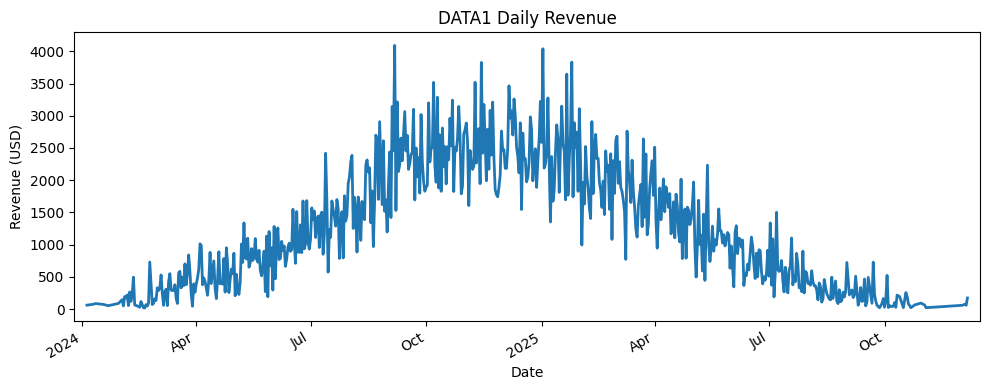

In [53]:
chart_dates = pd.to_datetime(daily_revenue["date"])
plt.figure(figsize=(10, 4))
plt.plot(chart_dates, daily_revenue["paid_price"], linewidth=2)
plt.title(f"{dataset_name} Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue (USD)")
axis = plt.gca()
padding = pd.Timedelta(days=10)
axis.set_xlim(chart_dates.min() - padding, chart_dates.max() + padding)
locator = mdates.AutoDateLocator(minticks=6, maxticks=9)
formatter = mdates.ConciseDateFormatter(locator)
axis.xaxis.set_major_locator(locator)
axis.xaxis.set_major_formatter(formatter)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "daily_revenue.png", dpi=150, bbox_inches="tight")
plt.show()


In [54]:
users.drop(columns=["name_key", "address_key", "phone_key", "email_key"]).to_csv(
    output_dir / "clean_users.csv", index=False
)
orders.to_csv(output_dir / "clean_orders.csv", index=False)
books.to_csv(output_dir / "clean_books.csv", index=False)
daily_revenue.to_csv(output_dir / "daily_revenue.csv", index=False)

result = {
    "dataset": dataset_name,
    "top_5_days_by_revenue": [
        {"date": row["date"], "revenue": round(float(row["paid_price"]), 2)}
        for _, row in top_5_days.iterrows()
    ],
    "unique_users": unique_users,
    "unique_author_sets": unique_author_sets,
    "most_popular_authors": most_popular_authors,
    "best_buyer_ids": best_buyer_ids,
    "best_buyer_total_spent": best_buyer_total_spent,
    "daily_revenue": [
        {"date": row["date"], "revenue": round(float(row["paid_price"]), 2)}
        for _, row in daily_revenue.iterrows()
    ],
}

with open(output_dir / "summary.json", "w", encoding="utf-8") as file:
    json.dump(result, file, indent=2)

results[dataset_name] = result

pd.DataFrame(
    [
        {
            "dataset": dataset_name,
            "top_day": result["top_5_days_by_revenue"][0]["date"],
            "top_day_revenue": result["top_5_days_by_revenue"][0]["revenue"],
            "unique_users": result["unique_users"],
            "unique_author_sets": result["unique_author_sets"],
            "most_popular_authors": ", ".join(result["most_popular_authors"]),
            "best_buyer_ids": str(result["best_buyer_ids"]),
        }
    ]
)


,dataset,top_day,top_day_revenue,unique_users,unique_author_sets,most_popular_authors,best_buyer_ids
0,DATA1,2024-09-06,4090.17,3115,325,Arlinda Huel,"[44850, 45062, 46955]"


## DATA2


In [55]:
dataset_name = "DATA2"
dataset_dir = DATA_DIR / dataset_name
output_dir = OUTPUT_DIR / dataset_name
output_dir.mkdir(parents=True, exist_ok=True)

users = pd.read_csv(dataset_dir / "users.csv", dtype=str).drop_duplicates().copy()
orders = pd.read_parquet(dataset_dir / "orders.parquet").drop_duplicates().copy()

with open(dataset_dir / "books.yaml", "r", encoding="utf-8") as file:
    books = pd.DataFrame(yaml.safe_load(file))

books.columns = [str(column).lstrip(":") for column in books.columns]

print(dataset_name)
print("users shape:", users.shape)
print("orders shape:", orders.shape)
print("books shape:", books.shape)


DATA2
users shape: (2810, 5)
orders shape: (9850, 7)
books shape: (741, 6)


Clean users


In [56]:
users["id"] = pd.to_numeric(users["id"], errors="coerce").astype("Int64")
users = users.dropna(subset=["id"]).copy()
users["id"] = users["id"].astype(int)

for column in ["name", "address", "phone", "email"]:
    users[column] = users[column].map(clean_text)

users.head(3)


,id,name,address,phone,email
0,53386,Jacqulyn Mante,"566 Emelina Turnpike, Lashundaside, NE 78034-5281",962.715.8009,leonardo.leannon@wintheiser-lueilwitz.example
1,54635,Devon Leannon III,,(537) 133-9394,jon_torp@bayer.example
2,55435,Shiloh Keebler,"425 Wesley Hills, Nathanialburgh, MS 08004",474.242.3397,murray_mcclure@pfeffer.example


Clean orders

In [57]:
orders["id"] = pd.to_numeric(orders["id"], errors="coerce").astype("Int64")
orders["user_id"] = pd.to_numeric(orders["user_id"], errors="coerce").astype("Int64")
orders["book_id"] = pd.to_numeric(orders["book_id"], errors="coerce").astype("Int64")
orders["quantity"] = pd.to_numeric(orders["quantity"], errors="coerce").astype("Int64")

orders = orders.dropna(subset=["id", "user_id", "book_id", "quantity"]).copy()

orders["id"] = orders["id"].astype(int)
orders["user_id"] = orders["user_id"].astype(int)
orders["book_id"] = orders["book_id"].astype(int)
orders["quantity"] = orders["quantity"].astype(int)

for column in ["unit_price", "timestamp", "shipping"]:
    orders[column] = orders[column].map(clean_text)

orders["unit_price_usd"] = orders["unit_price"].map(parse_price)
orders["timestamp_dt"] = orders["timestamp"].map(parse_timestamp)
orders["paid_price"] = (orders["quantity"] * orders["unit_price_usd"]).round(2)
orders["date"] = orders["timestamp_dt"].dt.strftime("%Y-%m-%d")
orders["year"] = orders["timestamp_dt"].dt.year
orders["month"] = orders["timestamp_dt"].dt.month
orders["day"] = orders["timestamp_dt"].dt.day

orders[["unit_price", "unit_price_usd", "timestamp", "timestamp_dt", "paid_price"]].head(5)


,unit_price,unit_price_usd,timestamp,timestamp_dt,paid_price
0,73.5$,73.5,"08:47:31 P.M.,10/07/24",2024-10-07 20:47:31,73.5
1,$25.00,25.0,2024-09-11T05:27:49,2024-09-11 05:27:49,25.0
2,USD22.50,22.5,"2024-08-06,06:53",2024-08-06 06:53:00,22.5
3,42.5$,42.5,03/18/25;09:32:41 AM,2025-03-18 09:32:41,42.5
4,$ 62.5,62.5,"04:55:14 pm,09/24/24",2024-09-24 16:55:14,62.5


Clean books


In [58]:
books["id"] = pd.to_numeric(books["id"], errors="coerce").astype("Int64")
books["year"] = pd.to_numeric(books["year"], errors="coerce").astype("Int64")
books = books.dropna(subset=["id"]).copy()
books["id"] = books["id"].astype(int)

for column in ["title", "author", "genre", "publisher"]:
    books[column] = books[column].map(clean_text)

books["author_set"] = books["author"].apply(
    lambda value: tuple(sorted([name.strip() for name in value.split(",") if name.strip()]))
)
books["author_set_name"] = books["author_set"].apply(lambda value: ", ".join(value))

books[["id", "title", "author", "author_set_name"]].head(5)


,id,title,author,author_set_name
0,21326,Behold the Man,"Trenton Sipes, Clint Hauck VM","Clint Hauck VM, Trenton Sipes"
1,21546,The Deer Hunter,Norris Gusikowski,Norris Gusikowski
2,21130,Snatch,Rev. Lura Jaskolski,Rev. Lura Jaskolski
3,21287,Dial M for Murder,Miss Elmo Walsh,Miss Elmo Walsh
4,21237,The Departed,Mario Aufderhar,Mario Aufderhar


In [59]:
users["name_key"] = users["name"].str.lower()
users["address_key"] = users["address"].str.lower()
users["phone_key"] = users["phone"].str.replace(r"\D", "", regex=True)
users["email_key"] = users["email"].str.lower()

parent = {user_id: user_id for user_id in users["id"].tolist()}
key_columns = ["name_key", "address_key", "phone_key", "email_key"]

for skipped_column in key_columns:
    current_columns = [column for column in key_columns if column != skipped_column]
    seen = {}

    for row in users[["id"] + current_columns].itertuples(index=False):
        user_id = row[0]
        key = row[1:]

        if any(value == "" for value in key):
            continue

        if key in seen:
            union_parent(parent, user_id, seen[key])
        else:
            seen[key] = user_id

users["real_user_id"] = users["id"].map(lambda user_id: find_parent(parent, user_id))
unique_users = int(users["real_user_id"].nunique())

unique_users


2663

Daily revenue and top 5 days.


In [60]:
daily_revenue = (
    orders.dropna(subset=["date", "paid_price"])
    .groupby("date", as_index=False)["paid_price"]
    .sum()
    .sort_values("date")
    .reset_index(drop=True)
)

daily_revenue["paid_price"] = daily_revenue["paid_price"].round(2)

top_5_days = (
    daily_revenue.sort_values(["paid_price", "date"], ascending=[False, True])
    .head(5)
    .reset_index(drop=True)
)

top_5_days


,date,paid_price
0,2024-09-12,4051.35
1,2025-01-20,3697.53
2,2024-11-15,3667.92
3,2024-11-21,3631.19
4,2024-12-25,3572.11


Author statistics

In [61]:
unique_author_sets = int(books["author_set_name"].nunique())

book_sales = orders.groupby("book_id", as_index=False)["quantity"].sum()
books_with_sales = books.merge(book_sales, left_on="id", right_on="book_id", how="left")
books_with_sales["quantity"] = books_with_sales["quantity"].fillna(0).astype(int)

author_sales = (
    books_with_sales.groupby("author_set_name", as_index=False)["quantity"]
    .sum()
    .sort_values(["quantity", "author_set_name"], ascending=[False, True])
    .reset_index(drop=True)
)

top_quantity = author_sales["quantity"].max()
most_popular_authors = author_sales.loc[
    author_sales["quantity"] == top_quantity, "author_set_name"
].tolist()

print("unique author sets:", unique_author_sets)
print("most popular authors:", most_popular_authors)


unique author sets: 293
most popular authors: ['Hershel Treutel, Miss Modesto Denesik, Sen. Trula Bosco']


Best buyer


In [62]:
orders_with_users = orders.merge(
    users[["id", "real_user_id"]],
    left_on="user_id",
    right_on="id",
    how="left",
)

user_spending = (
    orders_with_users.groupby("real_user_id", as_index=False)["paid_price"]
    .sum()
    .sort_values(["paid_price", "real_user_id"], ascending=[False, True])
    .reset_index(drop=True)
)

best_buyer_total_spent = round(float(user_spending["paid_price"].max()), 2)
best_group_ids = user_spending.loc[
    user_spending["paid_price"] == user_spending["paid_price"].max(), "real_user_id"
].tolist()

best_buyer_ids = []
for group_id in best_group_ids:
    ids = users.loc[users["real_user_id"] == group_id, "id"].tolist()
    best_buyer_ids.extend(ids)

best_buyer_ids = sorted(set(best_buyer_ids))

print("best buyer ids:", best_buyer_ids)
print("best buyer total spent:", best_buyer_total_spent)


best buyer ids: [53583, 55058, 55420]
best buyer total spent: 1312.84


Plot the chart


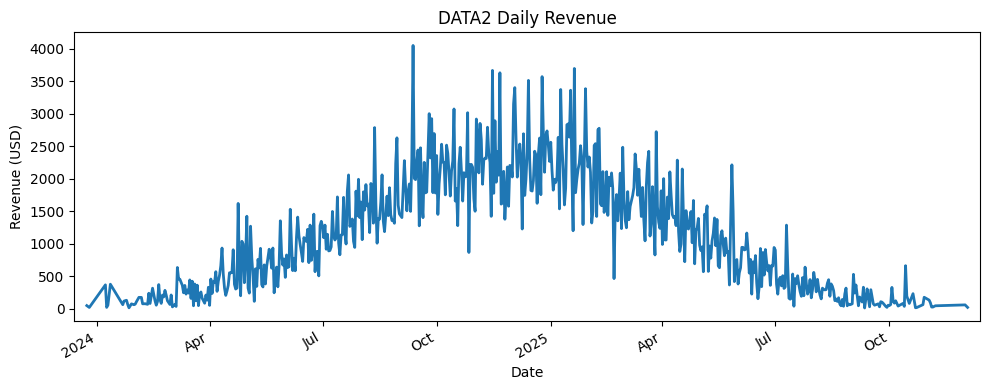

In [63]:
chart_dates = pd.to_datetime(daily_revenue["date"])
plt.figure(figsize=(10, 4))
plt.plot(chart_dates, daily_revenue["paid_price"], linewidth=2)
plt.title(f"{dataset_name} Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue (USD)")
axis = plt.gca()
padding = pd.Timedelta(days=10)
axis.set_xlim(chart_dates.min() - padding, chart_dates.max() + padding)
locator = mdates.AutoDateLocator(minticks=6, maxticks=9)
formatter = mdates.ConciseDateFormatter(locator)
axis.xaxis.set_major_locator(locator)
axis.xaxis.set_major_formatter(formatter)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "daily_revenue.png", dpi=150, bbox_inches="tight")
plt.show()


In [64]:
users.drop(columns=["name_key", "address_key", "phone_key", "email_key"]).to_csv(
    output_dir / "clean_users.csv", index=False
)
orders.to_csv(output_dir / "clean_orders.csv", index=False)
books.to_csv(output_dir / "clean_books.csv", index=False)
daily_revenue.to_csv(output_dir / "daily_revenue.csv", index=False)

result = {
    "dataset": dataset_name,
    "top_5_days_by_revenue": [
        {"date": row["date"], "revenue": round(float(row["paid_price"]), 2)}
        for _, row in top_5_days.iterrows()
    ],
    "unique_users": unique_users,
    "unique_author_sets": unique_author_sets,
    "most_popular_authors": most_popular_authors,
    "best_buyer_ids": best_buyer_ids,
    "best_buyer_total_spent": best_buyer_total_spent,
    "daily_revenue": [
        {"date": row["date"], "revenue": round(float(row["paid_price"]), 2)}
        for _, row in daily_revenue.iterrows()
    ],
}

with open(output_dir / "summary.json", "w", encoding="utf-8") as file:
    json.dump(result, file, indent=2)

results[dataset_name] = result

pd.DataFrame(
    [
        {
            "dataset": dataset_name,
            "top_day": result["top_5_days_by_revenue"][0]["date"],
            "top_day_revenue": result["top_5_days_by_revenue"][0]["revenue"],
            "unique_users": result["unique_users"],
            "unique_author_sets": result["unique_author_sets"],
            "most_popular_authors": ", ".join(result["most_popular_authors"]),
            "best_buyer_ids": str(result["best_buyer_ids"]),
        }
    ]
)


,dataset,top_day,top_day_revenue,unique_users,unique_author_sets,most_popular_authors,best_buyer_ids
0,DATA2,2024-09-12,4051.35,2663,293,"Hershel Treutel, Miss Modesto Denesik, Sen. Tr...","[53583, 55058, 55420]"


## DATA3


In [65]:
dataset_name = "DATA3"
dataset_dir = DATA_DIR / dataset_name
output_dir = OUTPUT_DIR / dataset_name
output_dir.mkdir(parents=True, exist_ok=True)

users = pd.read_csv(dataset_dir / "users.csv", dtype=str).drop_duplicates().copy()
orders = pd.read_parquet(dataset_dir / "orders.parquet").drop_duplicates().copy()

with open(dataset_dir / "books.yaml", "r", encoding="utf-8") as file:
    books = pd.DataFrame(yaml.safe_load(file))

books.columns = [str(column).lstrip(":") for column in books.columns]

print(dataset_name)
print("users shape:", users.shape)
print("orders shape:", orders.shape)
print("books shape:", books.shape)


DATA3
users shape: (3466, 5)
orders shape: (8933, 7)
books shape: (762, 6)


Clean users


In [66]:
users["id"] = pd.to_numeric(users["id"], errors="coerce").astype("Int64")
users = users.dropna(subset=["id"]).copy()
users["id"] = users["id"].astype(int)

for column in ["name", "address", "phone", "email"]:
    users[column] = users[column].map(clean_text)

users.head(3)


,id,name,address,phone,email
0,47856,Tammie Mayer,"Apt. 371 1875 Gusikowski Stravenue, Moenland, ...",163.212.2656,maire.larson@runolfsdottir-mclaughlin.example
1,49394,Evia Yost,"22610 Mildred Green, Pagacbury, AZ 19393-2103",778.926.6707,byron@johnston.test
2,48386,Margery Gorczany,"Apt. 884 349 Renner Lane, East Darren, NC 30837",992 375 5021,cletus@baumbach.test


Clean orders


In [67]:
orders["id"] = pd.to_numeric(orders["id"], errors="coerce").astype("Int64")
orders["user_id"] = pd.to_numeric(orders["user_id"], errors="coerce").astype("Int64")
orders["book_id"] = pd.to_numeric(orders["book_id"], errors="coerce").astype("Int64")
orders["quantity"] = pd.to_numeric(orders["quantity"], errors="coerce").astype("Int64")

orders = orders.dropna(subset=["id", "user_id", "book_id", "quantity"]).copy()

orders["id"] = orders["id"].astype(int)
orders["user_id"] = orders["user_id"].astype(int)
orders["book_id"] = orders["book_id"].astype(int)
orders["quantity"] = orders["quantity"].astype(int)

for column in ["unit_price", "timestamp", "shipping"]:
    orders[column] = orders[column].map(clean_text)

orders["unit_price_usd"] = orders["unit_price"].map(parse_price)
orders["timestamp_dt"] = orders["timestamp"].map(parse_timestamp)
orders["paid_price"] = (orders["quantity"] * orders["unit_price_usd"]).round(2)
orders["date"] = orders["timestamp_dt"].dt.strftime("%Y-%m-%d")
orders["year"] = orders["timestamp_dt"].dt.year
orders["month"] = orders["timestamp_dt"].dt.month
orders["day"] = orders["timestamp_dt"].dt.day

orders[["unit_price", "unit_price_usd", "timestamp", "timestamp_dt", "paid_price"]].head(5)


,unit_price,unit_price_usd,timestamp,timestamp_dt,paid_price
0,67.0 €,80.40,2025-01-11 09:50:11 PM,2025-01-11 21:50:11.000,80.40
1,EUR26.99,32.39,2024-03-27T07:46:55.055,2024-03-27 07:46:55.055,64.78
2,30 $,30.00,"11:17:51 PM, 29-JUN-2025",2025-06-29 23:17:51.000,30.00
3,18 $,18.00,09:29;11/06/24,2024-11-06 09:29:00.000,18.00
4,USD 24.99,24.99,2024-09-16;03:05:39 pm,2024-09-16 15:05:39.000,24.99


Clean books


In [68]:
books["id"] = pd.to_numeric(books["id"], errors="coerce").astype("Int64")
books["year"] = pd.to_numeric(books["year"], errors="coerce").astype("Int64")
books = books.dropna(subset=["id"]).copy()
books["id"] = books["id"].astype(int)

for column in ["title", "author", "genre", "publisher"]:
    books[column] = books[column].map(clean_text)

books["author_set"] = books["author"].apply(
    lambda value: tuple(sorted([name.strip() for name in value.split(",") if name.strip()]))
)
books["author_set_name"] = books["author_set"].apply(lambda value: ", ".join(value))

books[["id", "title", "author", "author_set_name"]].head(5)


,id,title,author,author_set_name
0,21778,Call of Duty: World at War,Elmer Parker,Elmer Parker
1,21374,WarioWare: Touched!,Ms. Kami Prosacco,Ms. Kami Prosacco
2,21457,Titanic: Music from the Motion Picture,Zoila Christiansen,Zoila Christiansen
3,21881,Flashdance: Original Soundtrack from the Motio...,"Joseph Raynor, Ja Ankunding II","Ja Ankunding II, Joseph Raynor"
4,21446,Riot!,Louanne Cruickshank,Louanne Cruickshank


In [69]:
users["name_key"] = users["name"].str.lower()
users["address_key"] = users["address"].str.lower()
users["phone_key"] = users["phone"].str.replace(r"\D", "", regex=True)
users["email_key"] = users["email"].str.lower()

parent = {user_id: user_id for user_id in users["id"].tolist()}
key_columns = ["name_key", "address_key", "phone_key", "email_key"]

for skipped_column in key_columns:
    current_columns = [column for column in key_columns if column != skipped_column]
    seen = {}

    for row in users[["id"] + current_columns].itertuples(index=False):
        user_id = row[0]
        key = row[1:]

        if any(value == "" for value in key):
            continue

        if key in seen:
            union_parent(parent, user_id, seen[key])
        else:
            seen[key] = user_id

users["real_user_id"] = users["id"].map(lambda user_id: find_parent(parent, user_id))
unique_users = int(users["real_user_id"].nunique())

unique_users


3290

Daily revenue and top 5 days.


In [70]:
daily_revenue = (
    orders.dropna(subset=["date", "paid_price"])
    .groupby("date", as_index=False)["paid_price"]
    .sum()
    .sort_values("date")
    .reset_index(drop=True)
)

daily_revenue["paid_price"] = daily_revenue["paid_price"].round(2)

top_5_days = (
    daily_revenue.sort_values(["paid_price", "date"], ascending=[False, True])
    .head(5)
    .reset_index(drop=True)
)

top_5_days


,date,paid_price
0,2024-11-16,3688.20
1,2025-01-31,3341.99
2,2024-10-26,3127.92
3,2024-11-12,3034.54
4,2024-12-25,3009.62


Author statistics


In [71]:
unique_author_sets = int(books["author_set_name"].nunique())

book_sales = orders.groupby("book_id", as_index=False)["quantity"].sum()
books_with_sales = books.merge(book_sales, left_on="id", right_on="book_id", how="left")
books_with_sales["quantity"] = books_with_sales["quantity"].fillna(0).astype(int)

author_sales = (
    books_with_sales.groupby("author_set_name", as_index=False)["quantity"]
    .sum()
    .sort_values(["quantity", "author_set_name"], ascending=[False, True])
    .reset_index(drop=True)
)

top_quantity = author_sales["quantity"].max()
most_popular_authors = author_sales.loc[
    author_sales["quantity"] == top_quantity, "author_set_name"
].tolist()

print("unique author sets:", unique_author_sets)
print("most popular authors:", most_popular_authors)


unique author sets: 268
most popular authors: ['Coy Streich, Keeley Hand, Lela Emard']


Best buyer

In [72]:
orders_with_users = orders.merge(
    users[["id", "real_user_id"]],
    left_on="user_id",
    right_on="id",
    how="left",
)

user_spending = (
    orders_with_users.groupby("real_user_id", as_index=False)["paid_price"]
    .sum()
    .sort_values(["paid_price", "real_user_id"], ascending=[False, True])
    .reset_index(drop=True)
)

best_buyer_total_spent = round(float(user_spending["paid_price"].max()), 2)
best_group_ids = user_spending.loc[
    user_spending["paid_price"] == user_spending["paid_price"].max(), "real_user_id"
].tolist()

best_buyer_ids = []
for group_id in best_group_ids:
    ids = users.loc[users["real_user_id"] == group_id, "id"].tolist()
    best_buyer_ids.extend(ids)

best_buyer_ids = sorted(set(best_buyer_ids))

print("best buyer ids:", best_buyer_ids)
print("best buyer total spent:", best_buyer_total_spent)


best buyer ids: [49715, 50963]
best buyer total spent: 1207.48


Plot the chart


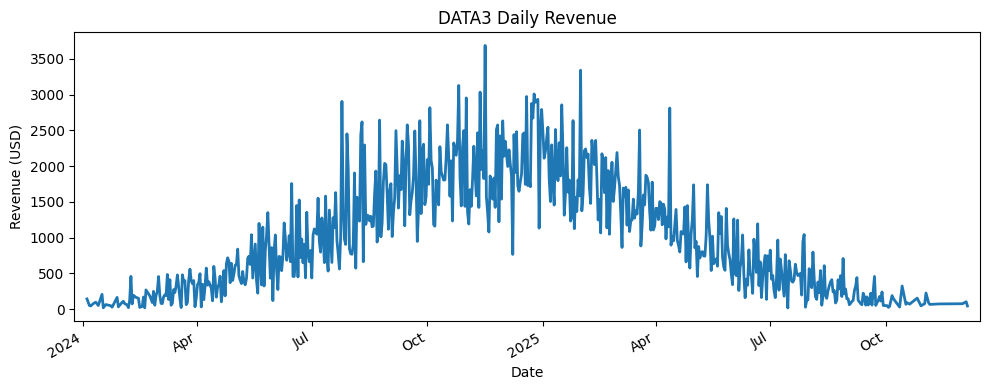

In [73]:
chart_dates = pd.to_datetime(daily_revenue["date"])
plt.figure(figsize=(10, 4))
plt.plot(chart_dates, daily_revenue["paid_price"], linewidth=2)
plt.title(f"{dataset_name} Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue (USD)")
axis = plt.gca()
padding = pd.Timedelta(days=10)
axis.set_xlim(chart_dates.min() - padding, chart_dates.max() + padding)
locator = mdates.AutoDateLocator(minticks=6, maxticks=9)
formatter = mdates.ConciseDateFormatter(locator)
axis.xaxis.set_major_locator(locator)
axis.xaxis.set_major_formatter(formatter)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "daily_revenue.png", dpi=150, bbox_inches="tight")
plt.show()


In [74]:
users.drop(columns=["name_key", "address_key", "phone_key", "email_key"]).to_csv(
    output_dir / "clean_users.csv", index=False
)
orders.to_csv(output_dir / "clean_orders.csv", index=False)
books.to_csv(output_dir / "clean_books.csv", index=False)
daily_revenue.to_csv(output_dir / "daily_revenue.csv", index=False)

result = {
    "dataset": dataset_name,
    "top_5_days_by_revenue": [
        {"date": row["date"], "revenue": round(float(row["paid_price"]), 2)}
        for _, row in top_5_days.iterrows()
    ],
    "unique_users": unique_users,
    "unique_author_sets": unique_author_sets,
    "most_popular_authors": most_popular_authors,
    "best_buyer_ids": best_buyer_ids,
    "best_buyer_total_spent": best_buyer_total_spent,
    "daily_revenue": [
        {"date": row["date"], "revenue": round(float(row["paid_price"]), 2)}
        for _, row in daily_revenue.iterrows()
    ],
}

with open(output_dir / "summary.json", "w", encoding="utf-8") as file:
    json.dump(result, file, indent=2)

results[dataset_name] = result

pd.DataFrame(
    [
        {
            "dataset": dataset_name,
            "top_day": result["top_5_days_by_revenue"][0]["date"],
            "top_day_revenue": result["top_5_days_by_revenue"][0]["revenue"],
            "unique_users": result["unique_users"],
            "unique_author_sets": result["unique_author_sets"],
            "most_popular_authors": ", ".join(result["most_popular_authors"]),
            "best_buyer_ids": str(result["best_buyer_ids"]),
        }
    ]
)


,dataset,top_day,top_day_revenue,unique_users,unique_author_sets,most_popular_authors,best_buyer_ids
0,DATA3,2024-11-16,3688.2,3290,268,"Coy Streich, Keeley Hand, Lela Emard","[49715, 50963]"


## Combined results


In [75]:
with open(OUTPUT_DIR / "results.json", "w", encoding="utf-8") as file:
    json.dump(results, file, indent=2)

final_table = pd.DataFrame(
    [
        {
            "dataset": dataset_name,
            "top_day": data["top_5_days_by_revenue"][0]["date"],
            "top_day_revenue": data["top_5_days_by_revenue"][0]["revenue"],
            "unique_users": data["unique_users"],
            "unique_author_sets": data["unique_author_sets"],
            "most_popular_authors": ", ".join(data["most_popular_authors"]),
            "best_buyer_ids": str(data["best_buyer_ids"]),
        }
        for dataset_name, data in results.items()
    ]
)

final_table


,dataset,top_day,top_day_revenue,unique_users,unique_author_sets,most_popular_authors,best_buyer_ids
0,DATA1,2024-09-06,4090.17,3115,325,Arlinda Huel,"[44850, 45062, 46955]"
1,DATA2,2024-09-12,4051.35,2663,293,"Hershel Treutel, Miss Modesto Denesik, Sen. Tr...","[53583, 55058, 55420]"
2,DATA3,2024-11-16,3688.20,3290,268,"Coy Streich, Keeley Hand, Lela Emard","[49715, 50963]"
